# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [6]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [8]:
df.info()
import matplotlib.pyplot as plt
import seaborn as sns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HoursWorked          300 non-null    float64
 1   FocusScore           300 non-null    float64
 2   ProductivityScore    300 non-null    float64
 3   Department           300 non-null    object 
 4   YearsAtCompany       300 non-null    int64  
 5   TeamMeetingsPerWeek  300 non-null    int64  
 6   DeskLocation         300 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 16.5+ KB


In [13]:
df.columns

Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation'],
      dtype='object')

#Years at Company Vs Productivity
this graph shows that there is no strong relationships between how long someone has been at the company and their productivity. The data points are spread out with no clear pattern. 

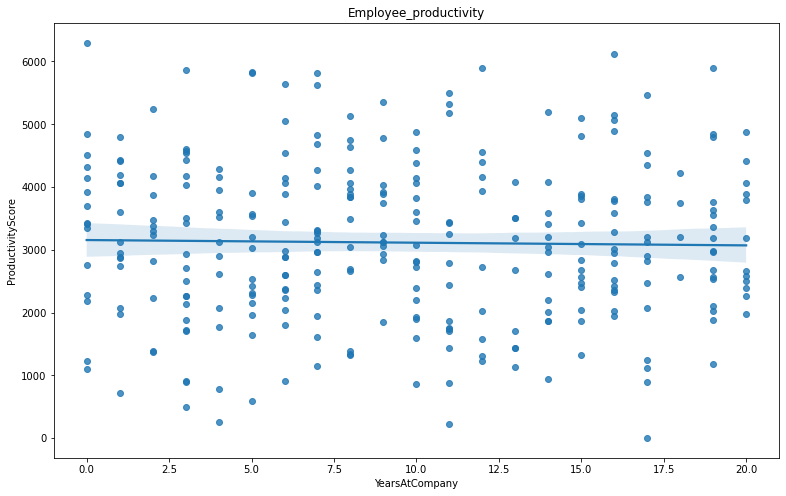

In [52]:
plt.figure(figsize=(13,8))
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df)
plt.title('Employee_productivity')
plt.show()

The R2 value is low, which confirms that years at the company does not explain much of the variation in productivity. 

In [53]:
import statsmodels.api as sm
x = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.726
Time:                        23:32:30   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#Hours Worked vs Productivity
This graph shows a weak and slightly negative relationship between hours worked and productivity. The regression line slopes downward, that means working more hours does not necessarily increase productivity and even slightly decrease. The data is still very spread out, so the relationship is still not very strong.

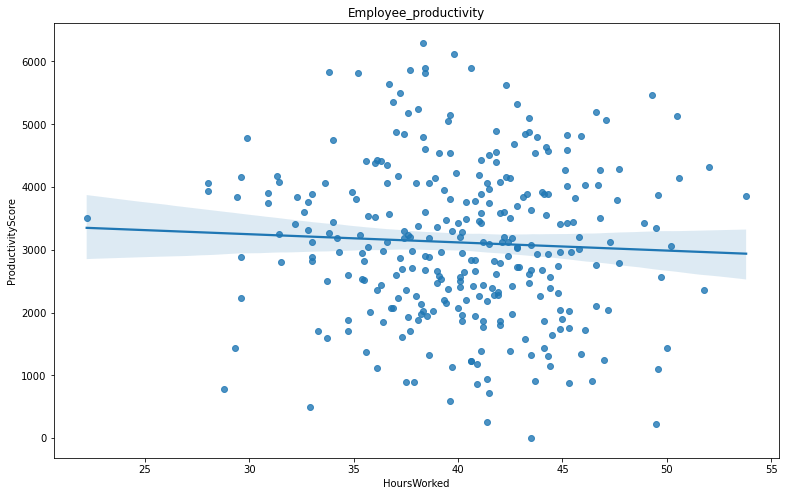

In [50]:
plt.figure(figsize=(13,8))
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df)
plt.title('Employee_productivity')
plt.show()

In [55]:
import statsmodels.api as sm
x = sm.add_constant(df['HoursWorked'])
y = df['ProductivityScore']
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.379
Time:                        23:35:14   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#Focus Score vs Productivity 
This graph shows a positive relationship between focus score and productivit. As focus increases, productivity as well increases. The data points follow an upward pattern, which makes this relationship much stronger then the others.

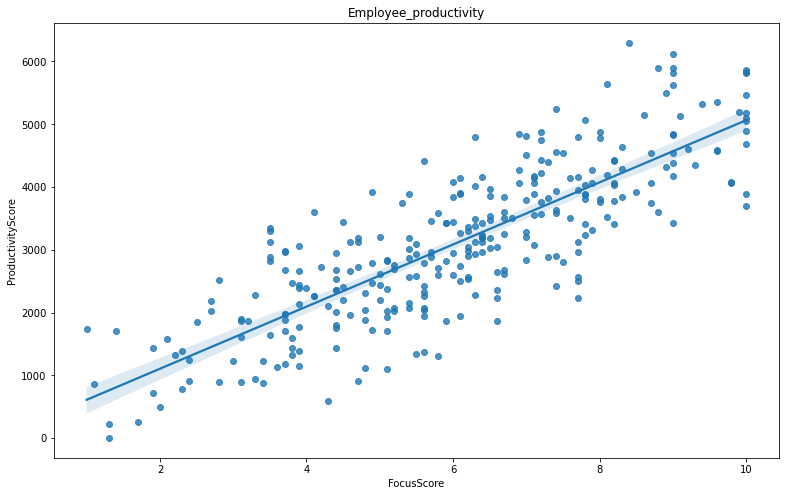

In [13]:
plt.figure(figsize=(13,8))
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Employee_productivity')
plt.show()

#The R2 value is the highest out all three variables showing that focus score explains a larger portion of the variation in productivity.

In [54]:
import statsmodels.api as sm
x = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.02e-75
Time:                        23:34:13   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##The R2 value is low once again which means hours is not strong predictor of productivity here. 

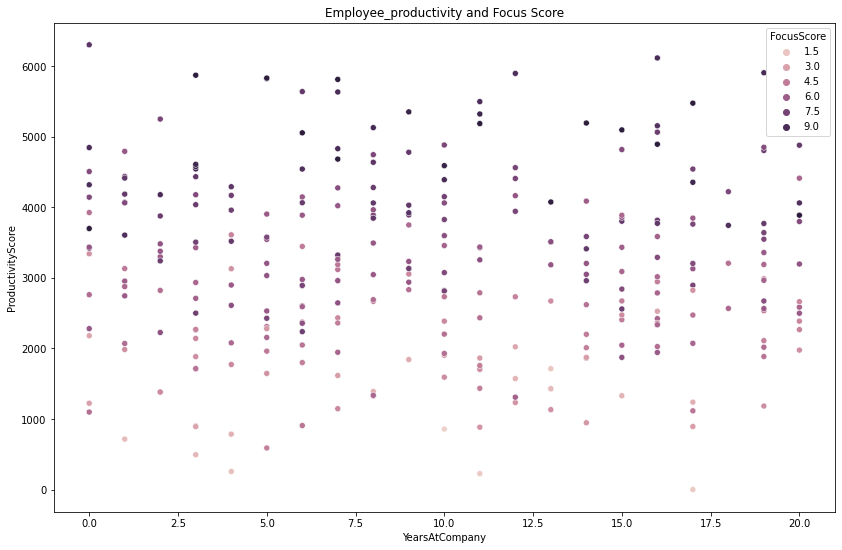

In [12]:
#Scatterplot of productivity score vs years spent in company
plt.figure(figsize=(14,9))
sns.scatterplot(x='YearsAtCompany', y='ProductivityScore', data=df, hue="FocusScore" )
plt.title('Employee_productivity and Focus Score')
plt.show()

In [ ]:
After building on the linear model, focus score still has the strongest impact on productivity. 
The Visualization show that higher focus levels consistently lead to higher productivity, even when considering other factors.

Text(0.5, 1.0, 'Meetings vs Productivity')

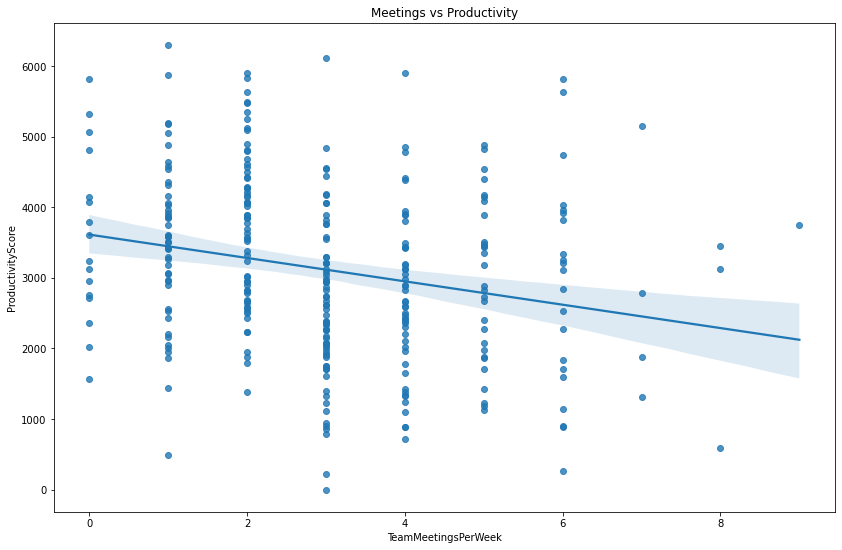

In [15]:
plt.figure(figsize=(14,9))
sns.regplot(x='TeamMeetingsPerWeek', y='ProductivityScore', data=df)
plt.title('Meetings vs Productivity')

In [16]:
import statsmodels.api as sm

X =sm.add_constant(df[['FocusScore', 'TeamMeetingsPerWeek', 'HoursWorked', 'YearsAtCompany']]) 
y = df['ProductivityScore']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     155.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.83e-71
Time:                        01:13:11   Log-Likelihood:                -2393.8
No. Observations:                 300   AIC:                             4798.
Df Residuals:                     295   BIC:                             4816.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 141.9005    

In [ ]:
Focus runs Everything, meetings slow people down and the rest don't really move the needle like that.

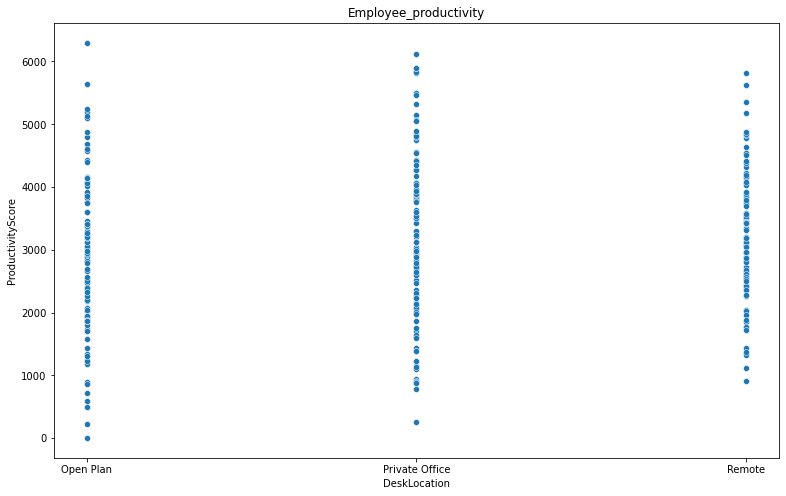

In [14]:
plt.figure(figsize=(13,8))
sns.scatterplot(x='DeskLocation', y='ProductivityScore', data=df)
plt.title('Employee_productivity')
plt.show()

A multiple linear regression model was built using focus score, team meetings per week, hours worked, and years at the company.
Focus score is the strongest factor, with higher focus leading to higher productivity. Meetings have a negative effect, meaning more meetings lower productivity. Hours worked and years at the company have little impact.
The combined model improves prediction slightly, but focus remains the main driver of productivity.